In [ ]:
%cd ..
from experiment_control.srs_microscope.srs_microscope import *
from scipy.signal import find_peaks
%matplotlib widget

c:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


c:\Users\euyehara
Opening connnection to Keithley source meter
Opening connection to Agilent E3633A DC Power Supply
VOA initialized to 4.99 volt


loading file: Spectra_test0_agiltron1301_70dB_2025-10-11-20-40-12.h5
importing Dev2...
importing HVA_Vraw...
importing HVA_Vset...
importing HV_arr...
importing VCSEL_wavmon_arr...
importing VCSEL_wavmon_raw...
importing VOA_Vset...
importing Vsrs_Vraw...
importing Vsrs_arr...
importing raman_shift...
importing t...
importing wavelength_set...
importing attr num_sweep...
importing attr pump_wav...
nanometer
importing attr pump_wav_units...
importing attr sens_lia...
millivolt
importing attr sens_lia_units...
importing attr t_lia...
microsecond
importing attr t_lia_units...
importing attr wav_start...
nanometer
importing attr wav_start_units...
importing attr wav_stop...
nanometer
importing attr wav_stop_units...
importing attr Δwav...
nanometer
importing attr Δwav_units...


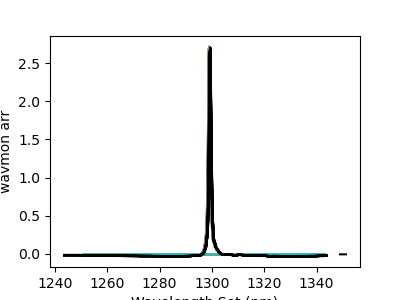

uncal pk: 1298.9897371714644
cal pk: 1299.2886233551885 nanometer


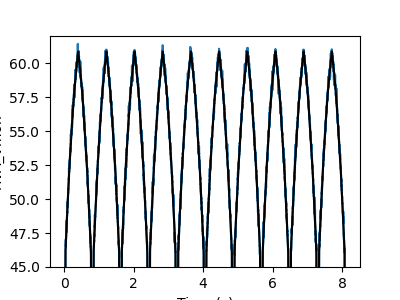

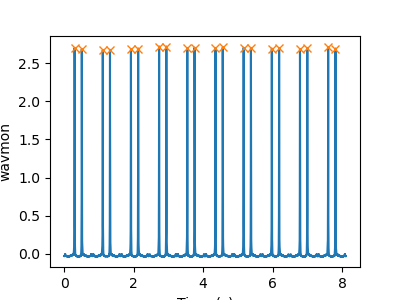

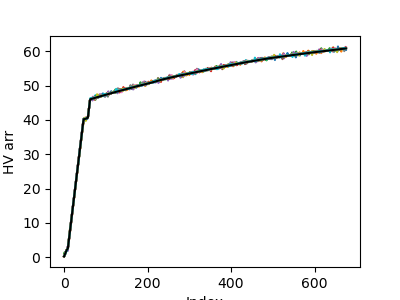

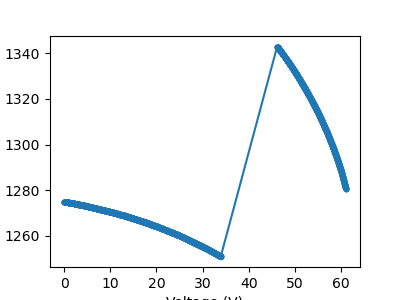

In [ ]:
data_dir = os.path.join(home_dir,"OneDrive","Documents","data","srs_microscope")

dir_name = "Sample_CWdev1b_testSweep_2025-10-11-18-54-35"
fname = "Spectra_test0_agiltron1301_70dB_2025-10-11-20-40-12.h5"
fpath = os.path.join(data_dir, dir_name)

ds = load_data_from_file(fpath, fname)
num_sweep = 20

agiltron_pks, _ = find_peaks(ds['VCSEL_wavmon_raw'], height=1)
vset_sweep = VCSEL_sweep_volts(ds['HVA_Vset'], num_sweep)

wavvolt_HVCALIB = os.path.join(calib_dir, "wavvolt_HVCALIB_CWdev1b_testSweep_nan_2025-10-16.mat") #For post-acquisition wavelength calibration
V_calib = calibrate_sweepSpectra(ds['wavelength_set'], ds['VCSEL_wavmon_arr'], ds['HV_arr'], ds['HVA_Vset'], wavvolt_HVCALIB=wavvolt_HVCALIB)
# wavvolt_file = os.path.join(calib_dir,"wavvolt_dev1b_15C_CW976_boa_0.00mW_2025-10-11.mat")
wavvolt_file = os.path.join(calib_dir,"wavvolt_dev1b_15C_CW976_boa_0.00mW_2025-10-11_FIXED2.mat")

 
 # Calibrate voltage to wavelength
a = io.loadmat(wavvolt_HVCALIB)
b = io.loadmat(wavvolt_file)
wav_calib =  (a['peak_interp'][0] * u.m).to(u.nm)
volt_calib = a['volt_interp'][0]*u.V
wav = (b['peak_interp'][0] * u.m).to(u.nm)
volt = b['volt_interp'][0]*u.V

wav_set = np.zeros(ds['HVA_Vset'].shape[0])
for i in range(ds['HVA_Vset'].shape[0]):
    w_ind = np.argmin(np.abs(ds['HVA_Vset'][i] - volt))
    wav_set[i] = wav[w_ind].m

plt.figure(figsize=(4,3))
plt.plot(ds['t'], Vmon_to_HVA(ds['HVA_Vraw']))
plt.plot(ds['t'][1:], vset_sweep, 'k')
plt.xlabel("Time (s)")
plt.ylabel("HVA_Vmon")
plt.ylim((45,62))

plt.figure(figsize=(4,3))
plt.plot(ds['t'], ds['VCSEL_wavmon_raw'])
plt.plot(ds['t'][agiltron_pks], ds['VCSEL_wavmon_raw'][agiltron_pks], 'x')
plt.xlabel("Time (s)")
# plt.xlim((1.5,2.5))
plt.ylabel("wavmon")


plt.figure(figsize=(4,3))
plt.plot(ds["HV_arr"].T)
plt.plot(ds['HVA_Vset'], 'k')
plt.xlabel("Index")
plt.ylabel("HV arr")
# ds["HV_arr"].shape

plt.figure(figsize=(4,3))
plt.plot(wav_set, ds["VCSEL_wavmon_arr"].T)
plt.plot(ds['wavelength_set'], V_calib.T, 'k')
plt.xlabel("Wavelength Set (nm)")
plt.ylabel("wavmon arr")
plt.show()

uncal_ind = np.nanargmax(np.mean(ds["VCSEL_wavmon_arr"], axis=0))
uncal_pk = wav_set[uncal_ind]
cal_ind = np.nanargmax(np.mean(V_calib, axis=0))
cal_pk = ds['wavelength_set'][cal_ind]
print(f"uncal pk: {uncal_pk}")
print(f"cal pk: {cal_pk}")

fig, ax = plt.subplots(1,1,figsize=(4,3))
# plt.plot(ds['HVA_Vset'], ds['wavelength_set'])
ax.plot(volt, wav, marker='.')
ax.plot(volt_calib, wav_calib)
ax.set_xlabel("Voltage (V)")
ax.set_ylabel("Wavelength (nm)")
mplcursors.cursor(ax)


t_1300_5 = ds['t'][agiltron_pks]
# print(t_1300_5)
# vmon_1300_5 = Vmon_to_HVA(ds['HVA_Vraw'][agiltron_pks])
# vset_1300_5 = vset_sweep[agiltron_pks]


loading file: Spectra_test1_FFP-I_40dB_0.1nmStep_2025-10-16-14-43-36.h5
importing Dev2...
importing HVA_Vraw...
importing HVA_Vset...
importing HV_arr...
importing VCSEL_wavmon_arr...
importing VCSEL_wavmon_raw...
importing VOA_Vset...
importing Vsrs_Vraw...
importing Vsrs_arr...
importing raman_shift...
importing t...
importing wavelength_set...
importing attr num_sweep...
importing attr pump_wav...
nanometer
importing attr pump_wav_units...
importing attr sens_lia...
millivolt
importing attr sens_lia_units...
importing attr t_lia...
microsecond
importing attr t_lia_units...
importing attr wav_start...
nanometer
importing attr wav_start_units...
importing attr wav_stop...
nanometer
importing attr wav_stop_units...
importing attr Δwav...
nanometer
importing attr Δwav_units...
FFP_pks: [  241   255   270   285   300   315   329   343   357   370   398   425
   969   983   996  1010  1024  1038  1053  1068  1098  1138  1579  1592
  1607  1621  1636  1651  1666  1681  1694  1708  1736  17

(263,)

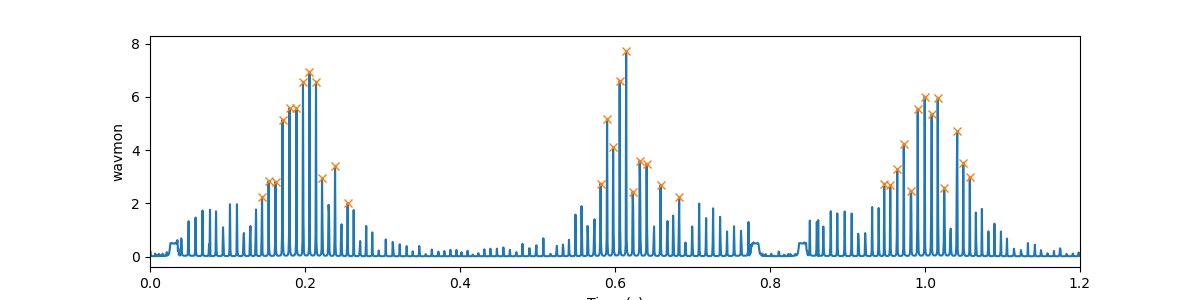

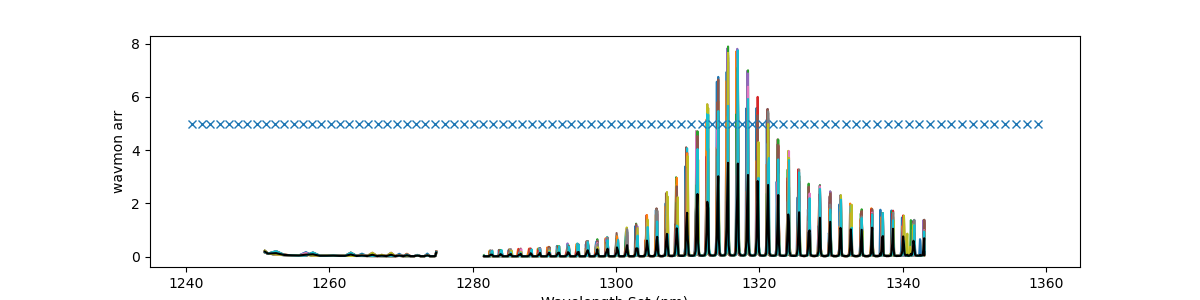

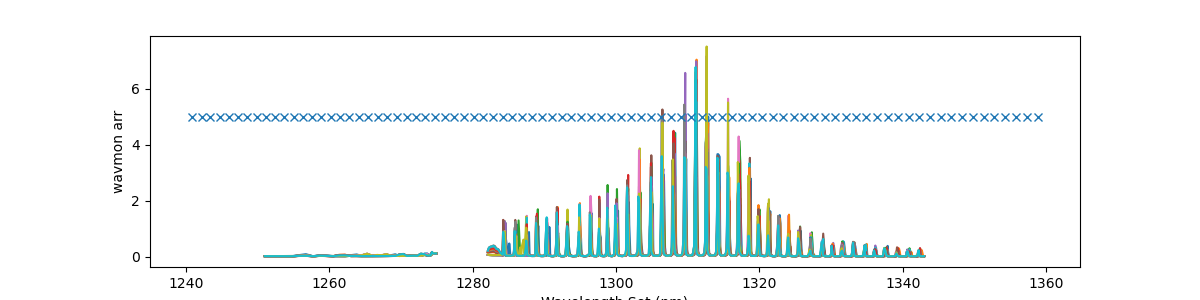

In [73]:


dir_name = "Sample_CWdev1b_testSweep_2025-10-11-18-54-35"
fname ="Spectra_test1_FFP-I_40dB_0.1nmStep_2025-10-16-14-43-36.h5"
# fname = "Spectra_test0_agiltron1301_70dB_2025-10-11-20-40-12.h5"
fpath = os.path.join(data_dir, dir_name)


ds0 = load_data_from_file(fpath, fname)
FFP_pks, _ = find_peaks(ds0['VCSEL_wavmon_raw'], distance=7, height=2)
print(f"FFP_pks: {FFP_pks}")

invalid_range = (35,45) * u.V
wav_set2 = np.zeros(ds0['HVA_Vset'].shape[0])
for i in range(ds0['HVA_Vset'].shape[0]):
    if (ds0['HVA_Vset'][i] >= invalid_range[0]) & (ds0['HVA_Vset'][i] <= invalid_range[1]):
        wav_set2[i] = np.nan
    else:
        w_ind = np.argmin(np.abs(ds0['HVA_Vset'][i] - volt))
        wav_set2[i] = wav[w_ind].m

V_calib2 = calibrate_sweepSpectra(ds0['wavelength_set'], ds0['VCSEL_wavmon_arr'], ds0['HV_arr'], ds0['HVA_Vset'], wavvolt_HVCALIB=wavvolt_HVCALIB)


plt.figure(figsize=(12,3))
plt.plot(ds0['t'], ds0['VCSEL_wavmon_raw'])
plt.plot(ds0['t'][FFP_pks], ds0['VCSEL_wavmon_raw'][FFP_pks], 'x')
# plt.axvline(t_1300_5[2].m, color='k')
plt.xlim((0,1.2))
plt.xlabel("Time (s)")
plt.ylabel("wavmon")

FFP_cal = np.ones(FFP_cal_pks["peaks"].shape)*5

# plt.figure(figsize=(4,3))
# plt.plot(ds0["HV_arr"].T)
# plt.xlabel("Index")
# plt.ylabel("HV arr")
# ds0["HV_arr"].shape
fig, ax = plt.subplots(1, 1, figsize=(12,3))
ax.plot(wav_set2, ds0["VCSEL_wavmon_arr"].T)
ax.plot(wav_set2, np.mean(ds0["VCSEL_wavmon_arr"].T, axis=1), 'k')
ax.plot(FFP_cal_pks["peaks"], FFP_cal, 'x')
# plt.plot(ds0["VCSEL_wavmon_arr"].T)
ax.set_xlabel("Wavelength Set (nm)")
ax.set_ylabel("wavmon arr")
mplcursors.cursor(ax)
# plt.xlim((1275,1355))

fig, ax2 = plt.subplots(1, 1, figsize=(12,3))
ax2.plot(wav_set2, V_calib2.T)
# plt.plot(ds0["VCSEL_wavmon_arr"].T)
ax2.set_xlabel("Wavelength Set (nm)")
ax2.set_ylabel("wavmon arr")
ax2.plot(FFP_cal_pks["peaks"], FFP_cal, 'x')
mplcursors.cursor(ax2)

print(f"t: {ds0['t'][FFP_pks]}")
print(f"pks: {ds0['VCSEL_wavmon_raw'][FFP_pks]}")
FFP_pks.shape


In [60]:
import csv
from pathlib import Path
from scipy.signal import find_peaks

def load_csv(fname, fpath=fpath):
    a = np.zeros((2,2048))
    with open(fpath/Path(fname), mode='r', newline='') as file:
        csv_reader = csv.reader(file)
        ind = 0
        for row in csv_reader:
            if len(row) > 0:
                a[ind,:] = np.array(row)
                ind +=1
                
    wavelength = a[0,:]
    spec = a[1,:]
   
    return wavelength, spec
    

In [61]:

FFP_I_file = "BOA_micronOptics_FFP-I_6GHz_RBW0.1nm.csv"
BOA_file = "BOA_RBW0.1nm.csv"

wavelength_filt, spec_filt = load_csv(FFP_I_file)
wavelength_BOA, spec_BOA = load_csv(BOA_file)

T_filt = spec_filt - spec_BOA

peaks, _ = find_peaks(T_filt, distance=20)

plt.figure()
plt.plot(wavelength_filt*1e9, T_filt)
plt.plot(wavelength_filt[peaks]*1e9, T_filt[peaks], 'x')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Transmission (dB)")
# plt.xlim((1240, 1241.5))



FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\euyehara\\OneDrive\\Documents\\data\\srs_microscope\\Sample_CWdev1b_testSweep_2025-10-11-18-54-35\\BOA_micronOptics_FFP-I_6GHz_RBW0.1nm.csv'

In [63]:
# print(wavelength_filt[peaks]*1e9)
spath = fpath / Path('FFP-I_peaks')
# dump_hdf5(
#         {'peaks': wavelength_filt[peaks]*1e9*u.nm},
#         spath,
#         open_mode='x',
#     )

FFP_cal_pks = load_hdf5(fpath=spath)



loading file: FFP-I_peaks
importing peaks...


In [421]:
agiltron_wav = 1300.5*u.nm
start_wav = wav_set2[0]

wav_sweep = VCSEL_sweep_volts(wav_set2*u.nm, num_sweep)
wav_sweep = np.insert(wav_sweep, [0], wav_sweep[0])

#restrict FFP_cal_pks to tuning range
FFP_cal = FFP_cal_pks['peaks']
FFP_cal = FFP_cal[(FFP_cal.m >= np.nanmin(wav_set2)) & (FFP_cal.m <= np.nanmax(wav_set2))] 


#sort FFP_cal in order of wav_set2
reorder = []
for j in range(wav_set2.shape[0]):
    ind = np.argmin(np.abs(wav_set2[j] - FFP_cal.m))
    reorder.append(FFP_cal[ind].m)
reorder_sweep = VCSEL_sweep_volts(np.array(reorder)*u.V, num_sweep)
reorder_sweep = np.insert(reorder_sweep, [0], reorder_sweep[0])

#create expected array of FFP time pulses
# FFP_pk_est = np.zeros(wav_set2.shape[0])
FFP_pk_est = []
for i in range(1,reorder_sweep.shape[0]):
    if reorder_sweep[i] != reorder_sweep[i-1]:
        FFP_pk_est.append(int(i))

FFP_pk_est = np.array(FFP_pk_est)

#Remove repeated values
FFP_cal_reorder = np.array([reorder[i] for i in range(len(reorder)) if i==0 or reorder[i] != reorder[i-1]])
print(FFP_cal_reorder)


# for i in range(wav_set2.shape[0]):
#     ind = np.argmin(np.abs(wav_set2 - FFP_cal_reorder))
#     FFP_pk_est[i]
    
# ind = np.diff(reorder)
# ind = np.insert(ind, [0], [1])
# print((ind>0).shape)
# print(wav_set2.shape)
# FFP_pk_est[ind > 0] = 1

    
#Find pk number corresponding to agiltron wavelength
FFP_ind = np.argmin(np.abs(agiltron_wav.m - FFP_cal_reorder))
pk_num = FFP_ind + 1

print(FFP_cal_reorder.shape[0])
print(pk_num)

#Using wave

[1274.7630679  1273.4147533  1272.06643869 1270.77674646 1269.42843185
 1268.08011724 1266.79042501 1265.44211041 1264.15241817 1262.80410357
 1261.51441133 1260.16609673 1258.87640449 1257.58671226 1256.29702003
 1255.0073278  1253.71763556 1252.36932096 1251.1382511  1249.84855887
 1248.55886663 1247.2691744  1245.97948217 1244.68978994 1281.50464094
 1282.85295554 1285.54958476 1292.40840254 1295.16365413 1299.3258427
 1302.08109428 1313.33659013 1320.42989741 1327.64044944 1337.89936492
 1352.78944797 1351.26526624 1348.27552516 1346.75134343 1343.76160234
 1342.29604299 1340.83048363 1339.36492428 1337.89936492 1336.43380557
 1334.90962384 1333.44406448 1332.0371275  1330.57156815 1329.10600879
 1327.64044944 1326.23351246 1324.7679531  1323.30239375 1321.89545677
 1320.42989741 1319.02296043 1317.61602345 1316.15046409 1314.74352711
 1313.33659013 1311.92965315 1310.4640938  1309.05715681 1307.65021983
 1306.24328285 1304.83634587 1303.48803127 1302.08109428 1300.6741573
 1299.32

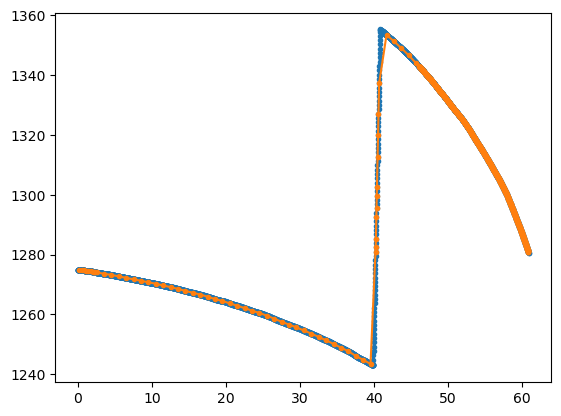

In [422]:
# plt.plot(reorder)
# plt.figure()
# plt.plot(FFP_pk_est*1)
# # plt.figure()
# # plt.plot(np.diff(reorder))
# # plt.plot(np.zeros(len(reorder)-1), '--')
# # print(reorder)
# # print(np.diff(reorder))
# # len(FFP_pk_est)
# print(wav_sweep.shape)
# print(ds0['t'].shape)
plt.plot(volt, wav, marker='.')
plt.plot(ds0['HVA_Vset'],wav_set2, marker='.')

(13521,)
(13521,)


c:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\matplotlib\cbook.py:1398: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


(0.0, 0.4)

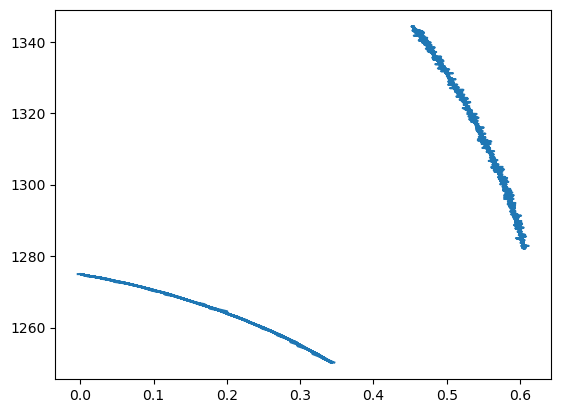

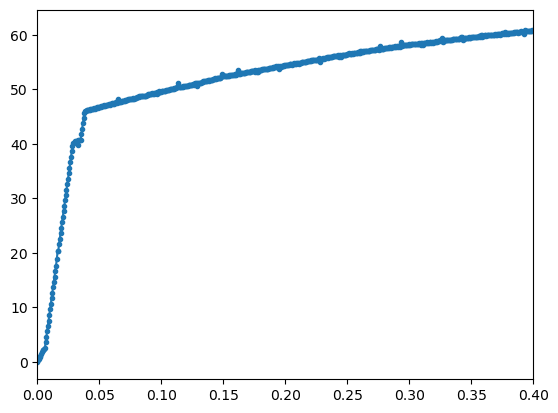

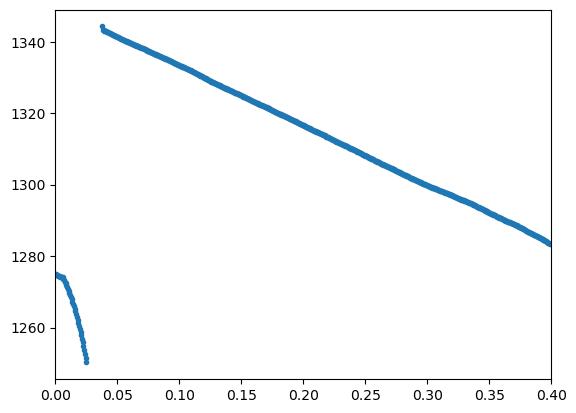

In [396]:
plt.plot(ds0['HVA_Vraw'], wav_sweep)

print(ds0['HVA_Vraw'].shape)
print(wav_sweep.shape)

plt.figure()
plt.plot(ds0['t'], Vmon_to_HVA(ds0['HVA_Vraw']), marker='.')
plt.xlim((0,0.4))
plt.figure()
plt.plot(ds0['t'], wav_sweep, marker='.')
plt.xlim((0,0.4))

[38, 63, 138, 163, 236, 261, 336, 361, 435, 461, 534, 560, 634, 660, 734, 760, 833, 859, 932, 958]


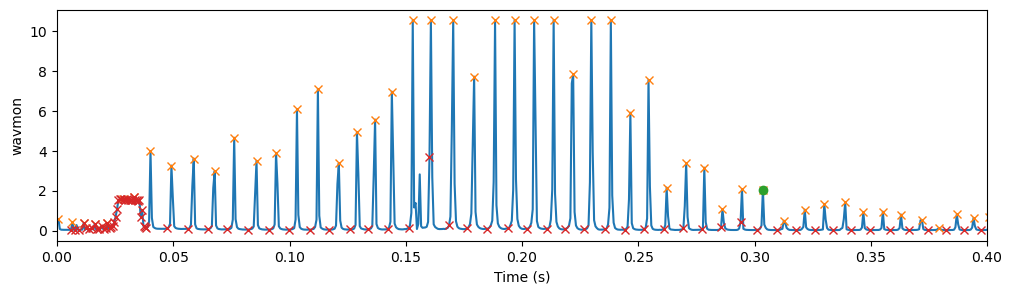

In [423]:
# agiltron_pks
# t_1300_5
# FFP_pks

t_FFP_pks = ds0['t'][FFP_pks]

# i_FFP_1300_5 = np.zeros(t_1300_5.shape[0])
i_FFP_1300_5 = []
for i in range(t_1300_5.shape[0]):
    ind = np.argmin(np.abs(t_FFP_pks - t_1300_5[i]))
    i_FFP_1300_5.append(int(ind))
    # t_FFP_1300_5[i] = t_FFP_pks[ind].m

FFP_pks_1300_5 = ds0['VCSEL_wavmon_raw'][FFP_pks][i_FFP_1300_5]
plt.figure(figsize=(12,3))
plt.plot(ds0['t'], ds0['VCSEL_wavmon_raw'])
plt.plot(ds0['t'][FFP_pks], ds0['VCSEL_wavmon_raw'][FFP_pks], 'x')
plt.plot(t_FFP_pks[i_FFP_1300_5], FFP_pks_1300_5, 'o')
plt.plot(ds0['t'][FFP_pk_est], ds0['VCSEL_wavmon_raw'][FFP_pk_est], 'x')

# plt.axvline(t_1300_5[2].m, color='k')
plt.xlim((0,0.4))
plt.xlabel("Time (s)")
plt.ylabel("wavmon")

print(i_FFP_1300_5)

In [226]:
FFP_pks

array([   60,    78,    93,   109,   123,   139,   155,   169,   184,
         200,   214,   226,   239,   248,   268,   284,   299,   314,
         329,   343,   358,   372,   386,   400,   414,   428,   441,
         456,   469,   483,   498,   514,   530,   545,   560,   575,
         589,   603,   618,   646,   680,   706,   720,   735,   750,
         764,   778,   793,   808,   823,   839,   855,   870,   884,
         897,   912,   925,   939,   953,   967,   981,   995,  1010,
        1024,  1039,  1054,  1069,  1084,  1099,  1114,  1127,  1140,
        1154,  1169,  1184,  1199,  1215,  1231,  1245,  1261,  1276,
        1428,  1444,  1459,  1474,  1490,  1505,  1520,  1535,  1551,
        1565,  1577,  1591,  1605,  1620,  1636,  1651,  1666,  1681,
        1695,  1709,  1723,  1738,  1752,  1765,  1779,  1792,  1807,
        1820,  1835,  1849,  1865,  1881,  1896,  1926,  1940,  1954,
        1969,  1984,  1997,  2011,  2023,  2059,  2073,  2088,  2116,
        2131,  2145,

In [397]:
from pint import UnitRegistry

In [443]:
wv_file = calib_dir / Path("wavvolt_dev1b_15C_CW976_boa_0.00mW_2025-10-11_FIXED2.mat")
wav_start = 1274*u.nm #1280*u.nm #1249*u.nm
wav_stop = 1343*u.nm #1342*u.nm #1276.8*u.nm
Δwav = 0.1*u.nm 
wavelength_set = generate_valid_sweep(wav_start, wav_stop, Δwav, wavvolt_file=wv_file)

daq_HVset, VOA_Vset, HVA_Vset, wavelength_set = parse_wav_delay(wavelength_set, wv_file, delayvolt_file=None)
V_MEMS_sweep = VCSEL_sweep_volts(daq_HVset, num_sweep)
V_VOA_sweep = VCSEL_sweep_volts(VOA_Vset, num_sweep)

Wavelength out of range: 1275.00 nanometer
Wavelength out of range: 1275.10 nanometer
Wavelength out of range: 1275.20 nanometer
Wavelength out of range: 1275.30 nanometer
Wavelength out of range: 1275.40 nanometer
Wavelength out of range: 1275.50 nanometer
Wavelength out of range: 1275.60 nanometer
Wavelength out of range: 1275.70 nanometer
Wavelength out of range: 1275.80 nanometer
Wavelength out of range: 1275.90 nanometer
Wavelength out of range: 1276.00 nanometer
Wavelength out of range: 1276.10 nanometer
Wavelength out of range: 1276.20 nanometer
Wavelength out of range: 1276.30 nanometer
Wavelength out of range: 1276.40 nanometer
Wavelength out of range: 1276.50 nanometer
Wavelength out of range: 1276.60 nanometer
Wavelength out of range: 1276.70 nanometer
Wavelength out of range: 1276.80 nanometer
Wavelength out of range: 1276.90 nanometer
Wavelength out of range: 1277.00 nanometer
Wavelength out of range: 1277.10 nanometer
Wavelength out of range: 1277.20 nanometer
Wavelength 

c:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\matplotlib\cbook.py:1398: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


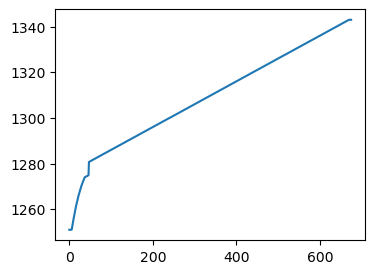

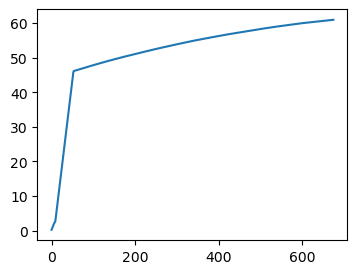

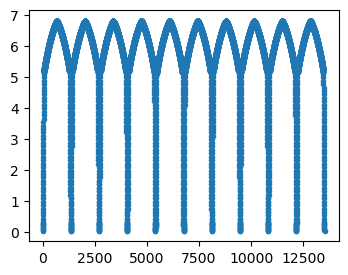

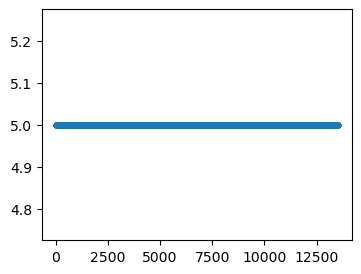

In [445]:
plt.figure(figsize=(4,3))
plt.plot(wavelength_set)
plt.figure(figsize=(4,3))
plt.plot(HVA_Vset)
plt.figure(figsize=(4,3))
plt.plot(V_MEMS_sweep, '.')
plt.figure(figsize=(4,3))
plt.plot(V_VOA_sweep, '.')


In [3]:
%matplotlib ipympl
%matplotlib widget

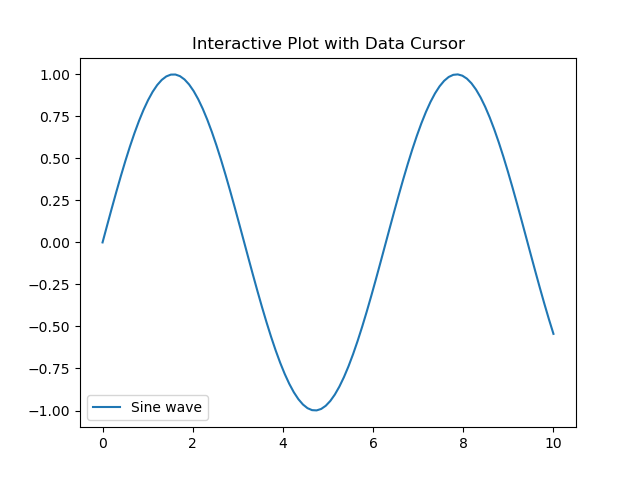

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import mplcursors

# Example data
x = np.linspace(0, 10, 100)
y = np.sin(x)

# Create the plot
fig, ax = plt.subplots()
ax.plot(x, y, label='Sine wave')
ax.set_title('Interactive Plot with Data Cursor')
ax.legend()


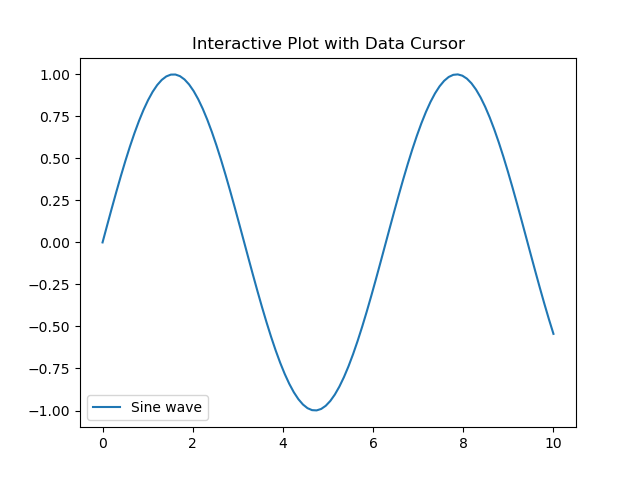

In [6]:
mplcursors.cursor(ax)
plt.show() # Optional, but can h